# 04 — Benchmark vs the RadChar Paper
Run the trained model on the test set and compare against the paper's Table 1
(accuracy + MAE) and Fig. 3 (metrics vs SNR).

In [1]:
import json
import numpy as np
import torch
import matplotlib.pyplot as plt

from radar.data import load_radchar, regression_targets, MinMaxNormaliser
from radar.model import RadarMTL

DATA_PATH = "../data/RadChar-Baseline.h5"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
REG_TASKS = RadarMTL.REGRESSION_TASKS  # (n_pulses, pw, pri, td)

In [2]:
iq, labels = load_radchar(DATA_PATH)
y_cls = labels["signal_type"].astype(np.int64)
reg   = regression_targets(labels)        # real units (count + µs)
snr   = labels["signal_to_noise_ratio"]

# the test split saved by notebook 03
test_idx = np.load("../results/test_idx.npy")
print(f"Test samples: {len(test_idx)}")

Test samples: 150000


In [3]:
model = RadarMTL().to(device)
model.load_state_dict(torch.load("../results/radar_mtl.pth", map_location=device))
model.eval()

# load the stats fitted in training: target min/max + I/Q mean/std
norm = MinMaxNormaliser.load("../results/norm_stats.json")
with open("../results/iq_stats.json") as f:
    iq_stats = json.load(f)
iq_mean, iq_std = iq_stats["mean"], iq_stats["std"]
print("Model and fitted stats loaded.")

Model and fitted stats loaded.


In [4]:
# run the model over a set of indices, batched.
# returns class predictions and regression predictions in real units.
def predict(idx, batch=512):
    cls_pred = np.empty(len(idx), dtype=np.int64)
    reg_pred = np.empty((len(idx), len(REG_TASKS)), dtype=np.float64)
    with torch.no_grad():
        for s in range(0, len(idx), batch):
            chunk = idx[s:s + batch]
            I = iq[chunk].real.astype(np.float32)
            Q = iq[chunk].imag.astype(np.float32)
            X = np.stack([I, Q], axis=1)
            X = ((X - iq_mean) / iq_std).astype(np.float32)  # same standardisation as training
            X = torch.tensor(X).to(device)
            out = model(X)
            cls_pred[s:s + len(chunk)] = out["signal_type"].argmax(1).cpu().numpy()
            scaled = np.stack([out[t].cpu().numpy() for t in REG_TASKS], axis=1)
            reg_pred[s:s + len(chunk)] = norm.inverse_transform(scaled)
    return cls_pred, reg_pred

In [5]:
# evaluate at every SNR level: accuracy + per-task MAE.
# feeds both the table and the figure below.
snr_levels = np.unique(snr)
acc_by_snr = []
mae_by_snr = []   # (n_levels, 4)

for level in snr_levels:
    idx = test_idx[snr[test_idx] == level]
    cls_pred, reg_pred = predict(idx)
    acc_by_snr.append((cls_pred == y_cls[idx]).mean())
    mae_by_snr.append(np.abs(reg_pred - reg[idx]).mean(axis=0))

acc_by_snr = np.array(acc_by_snr)
mae_by_snr = np.array(mae_by_snr)
print("Evaluated", len(snr_levels), "SNR levels.")

Evaluated 41 SNR levels.


In [6]:
# our row of Table 1, at the SNR points the paper tabulates (-10/0/+10 dB)
TABLE_SNR = [-10, 0, 10]
units = {"n_pulses": "count", "pw": "µs", "pri": "µs", "td": "µs"}

header = f"{'SNR (dB)':>8}  {'acc %':>6}  " + "  ".join(f"{t + ' MAE':>14}" for t in REG_TASKS)
print(header)
print("-" * len(header))
for level in TABLE_SNR:
    i = list(snr_levels).index(level)
    maes = "  ".join(f"{mae_by_snr[i, j]:>14.3f}" for j in range(len(REG_TASKS)))
    print(f"{level:>8}  {acc_by_snr[i] * 100:>6.1f}  {maes}")

print("\nUnits: n_pulses = count; pw / pri / td = microseconds.")
print("Compare against the paper's CNN1D / CNN2D / IQST-S / IQST-L rows in Table 1.")

SNR (dB)   acc %    n_pulses MAE          pw MAE         pri MAE          td MAE
--------------------------------------------------------------------------------
     -10    79.4           0.971           1.342           1.427           1.563
       0   100.0           0.162           0.367           0.448           0.396
      10   100.0           0.077           0.171           0.200           0.205

Units: n_pulses = count; pw / pri / td = microseconds.
Compare against the paper's CNN1D / CNN2D / IQST-S / IQST-L rows in Table 1.


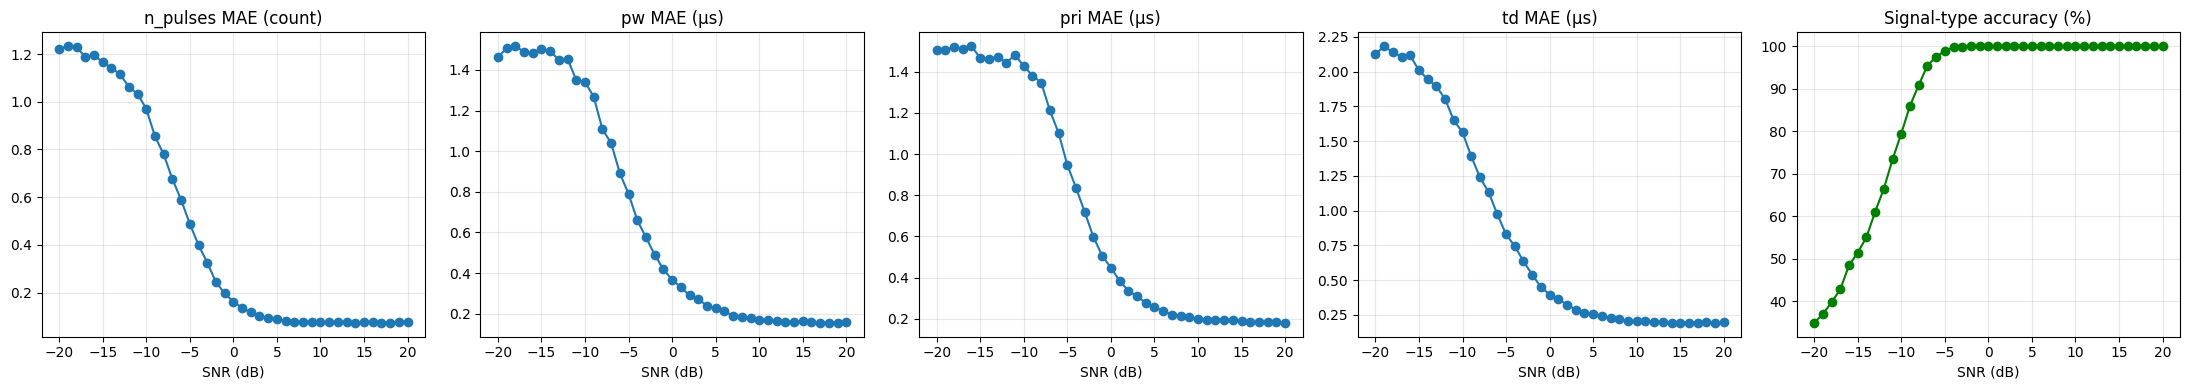

Saved results/benchmark_fig3.png


In [7]:
# --- Fig. 3: metrics across the full SNR range (4 MAE curves + 1 accuracy) ---
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for j, task in enumerate(REG_TASKS):
    axes[j].plot(snr_levels, mae_by_snr[:, j], marker="o")
    axes[j].set_title(f"{task} MAE ({units[task]})")
    axes[j].set_xlabel("SNR (dB)")
    axes[j].grid(True, alpha=0.3)

axes[4].plot(snr_levels, acc_by_snr * 100, marker="o", color="green")
axes[4].set_title("Signal-type accuracy (%)")
axes[4].set_xlabel("SNR (dB)")
axes[4].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../results/benchmark_fig3.png", dpi=150)
plt.show()
print("Saved results/benchmark_fig3.png")